In [9]:
from typing import Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')

/data/hyeryung/.conda/envs/loc-edit/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [10]:

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
def read_outputs(file_path):
    outputs = pd.read_json(file_path, lines=True)
    outputs = outputs.explode('generations',ignore_index=True)
    # outputs['generations'] = outputs['generations'].apply(lambda x: [x])
    outputs['prompt']=outputs['prompt'].apply(lambda x: x['text'])
    
    # outputs['text']=outputs['generations'].apply(lambda x: x['text'])
    
    gen_dict=outputs['generations'].values[0]
    
    for col in gen_dict.keys():
        outputs[col] = outputs['generations'].apply(lambda x: x.get(col,None))
        
    outputs.drop(columns=['generations'],inplace=True)
    return outputs

def read_int_outputs(file_path):
    outputs = pd.read_json(file_path, lines=True)
    outputs = outputs.explode('generations',ignore_index=True)
    # outputs['generations'] = outputs['generations'].apply(lambda x: [x])
    outputs['prompt']=outputs['prompt'].apply(lambda x: x['text'])
    
    # outputs['text']=outputs['generations'].apply(lambda x: x['text'])
    
    gen_dict=outputs['generations'].values[0]
    
    for col in gen_dict.keys():
        outputs[col] = outputs['generations'].apply(lambda x: x.get(col,None))
        
    outputs.drop(columns=['generations'],inplace=True)
    return outputs

def ravel(unraveled_df):
    if 'tokens' in unraveled_df:
        unraveled_df['generations']= unraveled_df.apply(lambda x: [{'text': x['text'],
                                                               'tokens': x['tokens']}],axis=1)
    else:
        unraveled_df['generations']= unraveled_df.apply(lambda x: [{'text': x['text']}],axis=1)
    return_df = unraveled_df.groupby('prompt')['generations'].sum([]).reset_index()
    return_df['prompt'] = return_df['prompt'].apply(lambda x: {'text':x})
        
    return return_df

In [11]:
def read_metric_file(result_file, metric) -> Union[np.array, pd.DataFrame]:
        
    if metric == 'ppl-big-qwen':
        result=pd.read_csv(result_file,header=None)
        return result
    
    elif metric == 'fluency':
        result=pd.read_csv(result_file,header=None)
        # return result[0].apply(lambda x: 1 if x=='LABEL_1' else 0).values
        result[0] = result[0].apply(lambda x: 1 if x=='LABEL_1' else 0)
        result.columns=['fluency_class','fluency_proba']
        return result
    
    elif metric == 'repetitions':
        result=pd.read_json(result_file,lines=True)
        if result.empty:
            return np.zeros(result.shape[0])
        else:
            return (~result['repeated_phrase'].isna()).apply(lambda x: 1 if x==True else 0).values
        
    elif metric == 'toxicity':
        result=pd.read_json(result_file,lines=True)
        return unravel_toxicity_data(result)
    
    elif metric == 'sentiment_ext':
        result=pd.read_json(result_file,lines=True)
        return result['label'].apply(lambda x: 1 if x == 'POSITIVE' else 0).values
    
    elif metric == 'formality_ext':
        result = pd.read_csv(result_file,header=None)
        return result[0].values
    
    elif metric == 'sbertscore':
        with open(result_file , 'r') as f:
            raw_data = f.readlines()
            tmp_data = []
            for x in raw_data[1:]:
                try:
                    tmp_data.append(float(x.strip()))
                except:
                    tmp_data.append(float("nan"))
        return np.array(tmp_data)    
    
    else:
        raise ValueError(f"Unknown metric {metric}") 
    

def read_nli_result(file_path):
    with open(file_path, 'r') as f:
        data = f.readlines()
    data = [eval(x.strip()) for x in data]
    data = pd.DataFrame.from_dict(data)
    return data

In [111]:
gemma_original = read_outputs('/data/hyeryung/mucoco/new_module/data/logical-consistency/gemma/filtered_0.9_r2-test_500_gemma-2-2b-it_49577.jsonl')
gemma_original_fluency = read_metric_file('/data/hyeryung/mucoco/new_module/data/logical-consistency/gemma/filtered_0.9_r2-test_500_gemma-2-2b-it_49577.jsonl-results.txt.fluency', 'fluency')
gemma_original_nli = read_nli_result('/data/hyeryung/mucoco/new_module/data/logical-consistency/gemma/filtered_0.9_r2-test_500_gemma-2-2b-it_49577.jsonl-results.txt.nli')
###

gemma_edited = read_outputs('/data/hyeryung/mucoco/outputs/nli/3llborj1/outputs_epsilon0.9.txt.intermediate').drop(columns=['iter0_update'])
gemma_edited_final = read_outputs('/data/hyeryung/mucoco/outputs/nli/3llborj1/outputs_epsilon0.9.txt')
gemma_edited_fluency = read_metric_file('/data/hyeryung/mucoco/outputs/nli/3llborj1/results_epsilon0.9-test.txt.fluency', 'fluency')
gemma_edited_nli = read_nli_result('/data/hyeryung/mucoco/outputs/nli/3llborj1/results_epsilon0.9-test.txt.nli')
###
gemma_edited_by_qwen = read_outputs('outputs/nli/wpddplgt/outputs_epsilon0.9.txt.intermediate').drop(columns=['iter0_update'])
gemma_edited_by_qwen_final = read_outputs('outputs/nli/wpddplgt/outputs_epsilon0.9.txt')
gemma_edited_by_qwen_fluency = read_metric_file('outputs/nli/wpddplgt/results_epsilon0.9-test.txt.fluency', 'fluency')
gemma_edited_by_qwen_nli = read_nli_result('outputs/nli/wpddplgt/results_epsilon0.9-test.txt.nli')

eda = pd.DataFrame({
    'premise': gemma_original['prompt'],
    'original': gemma_original['text'],
    'located': gemma_edited['iter0_masked_sentence'],
    # 'edited': gemma_edited['iter0_best_text'],
    'final': gemma_edited_final['text'],
    # 'edited_qwen': gemma_edited_by_qwen['iter0_best_text'],
    'final_qwen': gemma_edited_by_qwen_final['text'],
    'fluency_original': gemma_original_fluency['fluency_proba'],
    'fluency_final': gemma_edited_fluency['fluency_proba'],
    'fluency_final_qwen': gemma_edited_by_qwen_fluency['fluency_proba'],
    'nli_original': gemma_original_nli['nli_class'],
    'nli_final': gemma_edited_nli['nli_class'],
    'nli_final_qwen': gemma_edited_by_qwen_nli['nli_class']
})

### 원본 문장의 nli class 에 따른 고친 문장의 fluency 비교

- 가설: 원본에 contra가 없으면 고칠 때 억지로 (?) contra 부분을 찾아서 고쳐야 하니까 fluency가 떨어진다.
- 결론: 이게 그닥 엄청난 factor는 아닌것 같다.

In [31]:
print(eda.loc[eda['nli_original'].isin(['entail', 'neutral']), 'fluency_final'].mean())
print(eda.loc[eda['nli_original'].isin(['contradiction']), 'fluency_final'].mean())

0.7955343962682914
0.7902541340213932


In [32]:
print(eda.loc[eda['nli_original'].isin(['entail', 'neutral']), 'fluency_final'].median())
print(eda.loc[eda['nli_original'].isin(['contradiction']), 'fluency_final'].median())

0.8839592337608337
0.8973448872566223


In [36]:
a = eda.loc[eda['nli_original'].isin(['entail', 'neutral']), 'fluency_final'].quantile(np.arange(0, 1.1, 0.1))
b = eda.loc[eda['nli_original'].isin(['contradiction']), 'fluency_final'].quantile(np.arange(0, 1.1, 0.1))
ab = pd.concat([a,b],axis=1)
ab.columns=['original_cons', 'original_incons']
ab

,original_cons,original_incons
0.0,0.067578,0.111932
0.1,0.494783,0.403089
0.2,0.650465,0.626749
0.3,0.759616,0.788911
0.4,0.846604,0.827286
0.5,0.883959,0.897345
0.6,0.912728,0.915094
0.7,0.926486,0.938436
0.8,0.941377,0.949545
0.9,0.952610,0.958578


In [37]:
print(eda.loc[eda['nli_original'].isin(['entail', 'neutral']), 'fluency_final'].apply(lambda x: x> 0.5).value_counts()/eda['nli_original'].isin(['entail', 'neutral']).sum())
print(eda.loc[eda['nli_original'].isin(['contradiction']), 'fluency_final'].apply(lambda x: x> 0.5).value_counts()/eda['nli_original'].isin(['contradiction']).sum())

fluency_final
True     0.896552
False    0.103448
Name: count, dtype: float64
fluency_final
True     0.863014
False    0.136986
Name: count, dtype: float64


Text(0, 0.5, 'Count')

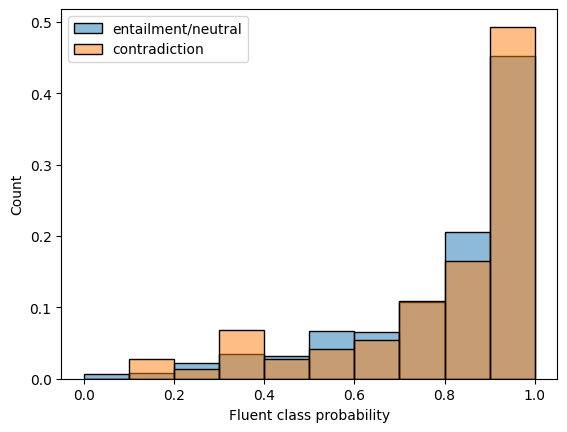

In [25]:
# fig, axes = plt.subplots(1,1, figsize=(10, 5))
sns.histplot(eda.loc[eda['nli_original'].isin(['entail', 'neutral']), 'fluency_final'],alpha=0.5,stat='probability',bins=np.arange(0,1.1,0.1))
sns.histplot(eda.loc[eda['nli_original'].isin(['contradiction']), 'fluency_final'],alpha=0.5,stat='probability',bins=np.arange(0,1.1,0.1))
plt.legend(['entailment/neutral', 'contradiction'])
plt.xlabel('Fluent class probability')
plt.ylabel('Count')

### 원본 문장의 길이에 따른 고친 문장의 fluency 비교

- 가설1: 원본 길이가 길면, L&E가 이상하게 고쳤어도 커버가 된다.
- 가설2: 원본 길이가 길면, L&E가 candidate generation을 더 잘하게 된다.
- 결론: 길이에 따른 trend도 명확하게 있지는 않다. (가령 길 수록 더 fluent하게 고친다거나))

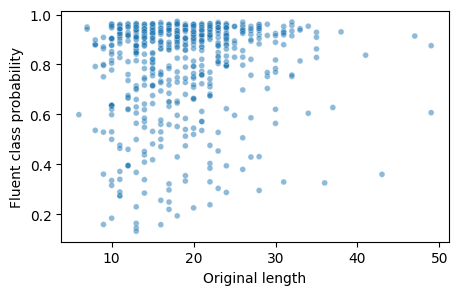

####################################################################################################
count    566.000000
mean      18.650177
std        6.598570
min        6.000000
25%       14.000000
50%       18.000000
75%       22.000000
max       49.000000
Name: original_len, dtype: float64
####################################################################################################
Mean
original_len_bins
(0, 10]     0.736759
(10, 20]    0.789427
(20, 30]    0.827010
(30, 40]    0.832706
(40, 60]    0.718645
Name: fluency_final_qwen, dtype: float64
####################################################################################################
####################################################################################################
fluency_final_qwen_class   0    1
original_len_bins                
(0, 10]                    5   41
(10, 20]                  37  282
(20, 30]                  13  158
(30, 40]                   2   23
(40, 60]                   1

In [114]:
eda['original_len'] = eda['original'].apply(lambda x: len(tokenizer(x)['input_ids']))

plt.figure(figsize=(5, 3))
sns.scatterplot(data=eda, x='original_len', y='fluency_final_qwen', size=1,alpha=0.5,legend=False)
plt.xlabel('Original length')
plt.ylabel('Fluent class probability')
plt.show()
print('#'*100)
print(eda['original_len'].describe())
print('#'*100)
eda['original_len_bins'] = pd.cut(eda['original_len'], [0,10,20,30,40,60])
eda['fluency_final_qwen_class'] = eda['fluency_final_qwen'].apply(lambda x: 1 if x > 0.5 else 0)
print('Mean')
print(eda.groupby('original_len_bins')['fluency_final_qwen'].mean())
print('#'*100)
# print('Median')
# print(eda.groupby('original_len_bins')['fluency_final_qwen'].median())
print('#'*100)
print(eda.groupby('original_len_bins')['fluency_final_qwen_class'].value_counts().unstack())
print('#'*100)

In [110]:
phi_original = read_outputs('/data/hyeryung/mucoco/new_module/data/logical-consistency/phi/filtered_0.9_r2-test_500_Phi-3.5-mini-instruct_49611_postprocess.jsonl')
phi_original_fluency = read_metric_file('/data/hyeryung/mucoco/new_module/data/logical-consistency/phi/filtered_0.9_r2-test_500_Phi-3.5-mini-instruct_49611_postprocess.jsonl-results.txt.fluency', 'fluency')
phi_original_nli = read_nli_result('/data/hyeryung/mucoco/new_module/data/logical-consistency/phi/filtered_0.9_r2-test_500_Phi-3.5-mini-instruct_49611_postprocess.jsonl-results.txt.nli')
###
phi_edited = read_outputs('/data/hyeryung/mucoco/outputs/nli/s22rovtt/outputs_epsilon0.9.txt.intermediate').drop(columns=['iter0_update'])
phi_edited_final = read_outputs('/data/hyeryung/mucoco/outputs/nli/s22rovtt/outputs_epsilon0.9.txt')
phi_edited_fluency = read_metric_file('/data/hyeryung/mucoco/outputs/nli/s22rovtt/results_epsilon0.9-test.txt.fluency', 'fluency')
phi_edited_nli = read_nli_result('/data/hyeryung/mucoco/outputs/nli/s22rovtt/results_epsilon0.9-test.txt.nli')
###
phi_edited_by_qwen = read_outputs('outputs/nli/vpivi02t/outputs_epsilon0.9.txt.intermediate').drop(columns=['iter0_update'])
phi_edited_by_qwen_final = read_outputs('outputs/nli/vpivi02t/outputs_epsilon0.9.txt')
phi_edited_by_qwen_fluency = read_metric_file('outputs/nli/vpivi02t/results_epsilon0.9-test.txt.fluency', 'fluency')
phi_edited_by_qwen_nli = read_nli_result('outputs/nli/vpivi02t/results_epsilon0.9-test.txt.nli')

phi_eda = pd.DataFrame({
    'premise': phi_original['prompt'],
    'original': phi_original['text'],
    'located': phi_edited['iter0_masked_sentence'],
    # 'edited': phi_edited['iter0_best_text'],
    'final': phi_edited_final['text'],
    # 'edited_qwen': phi_edited_by_qwen['iter0_best_text'],
    'final_qwen': phi_edited_by_qwen_final['text'],
    'fluency_original': phi_original_fluency['fluency_proba'],
    'fluency_final': phi_edited_fluency['fluency_proba'],
    'fluency_final_qwen': phi_edited_by_qwen_fluency['fluency_proba'],
    'nli_original': phi_original_nli['nli_class'],
    'nli_final': phi_edited_nli['nli_class'],
    'nli_final_qwen': phi_edited_by_qwen_nli['nli_class']
})

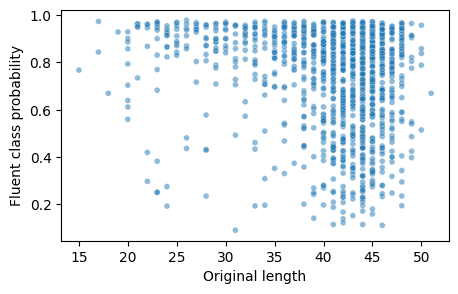

####################################################################################################
count    1211.000000
mean       40.523534
std         6.315538
min        15.000000
25%        38.000000
50%        42.000000
75%        45.000000
max        51.000000
Name: original_len, dtype: float64
####################################################################################################
Mean
original_len_bins
(0, 10]          NaN
(10, 20]    0.790060
(20, 30]    0.829537
(30, 40]    0.783253
(40, 60]    0.707863
Name: fluency_final_qwen, dtype: float64
####################################################################################################
fluency_final_qwen_class    0    1
original_len_bins                 
(0, 10]                     0    0
(10, 20]                    0   14
(20, 30]                   12   87
(30, 40]                   32  273
(40, 60]                  162  631
################################################################################

In [113]:
phi_eda['original_len'] = phi_eda['original'].apply(lambda x: len(tokenizer(x)['input_ids']))

plt.figure(figsize=(5, 3))
sns.scatterplot(data=phi_eda, x='original_len', y='fluency_final_qwen', size=1,alpha=0.5,legend=False)
plt.xlabel('Original length')
plt.ylabel('Fluent class probability')
plt.show()
print('#'*100)
print(phi_eda['original_len'].describe())
print('#'*100)
phi_eda['original_len_bins'] = pd.cut(phi_eda['original_len'], [0,10,20,30,40,60])
phi_eda['fluency_final_qwen_class'] = phi_eda['fluency_final_qwen'].apply(lambda x: 1 if x > 0.5 else 0)
print('Mean')
print(phi_eda.groupby('original_len_bins')['fluency_final_qwen'].mean())
print('#'*100)
# print('Median')
# print(phi_eda.groupby('original_len_bins')['fluency_final_qwen'].median())
# print('#'*100)
print(phi_eda.groupby('original_len_bins')['fluency_final_qwen_class'].value_counts().unstack())
print('#'*100)
print(phi_eda.groupby('original_len_bins')['fluency_final_qwen_class'].mean().round(3))
print('#'*100)

In [ ]:
phi_eda.sort_values(by='fluency_final').head(10)

,premise,original,located,edited,final,edited_qwen,final_qwen,fluency_original,fluency_final,fluency_final_qwen,nli_original,nli_final,nli_final_qwen
146,"""679"" is the second single by American rapper Fetty Wap from his self-titled debut album. The song features Remy Boyz member Monty and former Remy Boyz member P-Dice. ""679"" peaked at number 4 on the US ""Billboard"" Hot 100, becoming his second highest-charting single after ""Trap Queen"". The album version of the song omits P-Dice's verse, only featuring Monty.","""679"" is a single that reached number 4 on the US ""Billboard"" Hot 100 and exclusively features Monty in the album version.","""679"" is a single that reached number 4 on the US ""Billboard"" Hot 100 and<mask> features Monty in the album version.","""679"" is a single that reached number 4 on the US ""Billboard"" Hot 100 and was not only features Monty in the album version.","""679"" is a single that reached number 4 on the US ""Billboard"" Hot 100 and was not only features Monty in the album version.","""679"" is a single that reached number 4 on the US ""Billboard"" Hot 100 and features Monty in the album version.","""679"" is a single that reached number 4 on the US ""Billboard"" Hot 100 and features Monty in the album version.",0.765733,0.068474,0.691640,entail,neutral,neutral
696,"The Oakland County Child Killer (OCCK) is an unidentified serial killer responsible for the murders of four or more children, two girls and two boys, in Oakland County, Michigan, United States in 1976 and 1977. Several theories and suspects have been named in the case, but despite all these theories, the cases remain unsolved and the killer(s) have never been identified.","The is: The Oakland County Child Killer is confirmed to be a single individual who committed all the murders between 1976 and 1977 in Oakland County, Michigan. (Entailment )\n","The is: The Oakland County Child Killer is<mask> to be a single individual who committed all the murders between 1976 and 1977 in Oakland County, Michigan. (Entailment )\n","The is: The Oakland County Child Killer is not the suspected to be a single individual who committed all the murders between 1976 and 1977 in Oakland County, Michigan. (Entailment )\n","The is: The Oakland County Child Killer is not the suspected to be a single individual who committed all the murders between 1976 and 1977 in Oakland County, Michigan. (Entailment )\n","The is: The Oakland County Child Killer is believed to be a single individual who committed all the murders between 1976 and 1977 in Oakland County, Michigan. (Entailment )\n","The is: The Oakland County Child Killer is believed to be a single individual who committed all the murders between 1976 and 1977 in Oakland County, Michigan. (Entailment )\n",0.774979,0.114688,0.349135,contradiction,neutral,neutral
259,"The Exterminating Angel (Spanish: El ángel exterminador ), is a 1962 surrealist film, written and directed by Luis Buñuel, starring Silvia Pinal, and produced by her then-husband Gustavo Alatriste. Sharply satirical and allegorical, the film contains a view of human nature suggesting ""mankind harbors savage instincts and unspeakable secrets"".","The film El Ángel Exterminador, directed by Luis Buñuel, portrays that human nature is inherently savage and holds dark, unspoken truths, which entails the that the movie explores the darker",None,None,"The film El Ángel Exterminador, directed by Luis Buñuel, portrays that human nature is inherently savage and holds dark, unspoken truths, which entails the that the movie explores the darker",None,"The film El Ángel Exterminador, directed by Luis Buñuel, portrays that human nature is inherently savage and holds dark, unspoken truths, which entails the that the movie explores the darker",0.443263,0.121268,0.121268,entail,neutral,neutral
399,"""Hang On"" is a song by the band Weezer. The song impacted radio on February 15, 2011. It is the seventh track and second single from their eighth studio album, 

In [109]:
gpt35_original = read_outputs('/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl')
gpt35_original_fluency = read_metric_file('/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl-results.txt.fluency', 'fluency')
gpt35_original_nli = read_nli_result('/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl-results.txt.nli')
###
gpt35_edited_by_qwen = read_outputs('outputs/nli/k0tprzvq/outputs_epsilon0.99.txt.intermediate').drop(columns=['iter0_update'])
gpt35_edited_by_qwen_final = read_outputs('outputs/nli/k0tprzvq/outputs_epsilon0.99.txt')
gpt35_edited_by_qwen_fluency = read_metric_file('outputs/nli/k0tprzvq/outputs_epsilon0.99.txt-results.txt.fluency', 'fluency')
gpt35_edited_by_qwen_nli = read_nli_result('outputs/nli/k0tprzvq/results_epsilon0.99-test.txt.nli')
###
gpt35_edited_by_phi = read_outputs('outputs/nli/dgfyzktc/outputs_epsilon0.99.txt.intermediate').drop(columns=['iter0_update'])
gpt35_edited_by_phi_final = read_outputs('outputs/nli/dgfyzktc/outputs_epsilon0.99.txt')
gpt35_edited_by_phi_fluency = read_metric_file('outputs/nli/dgfyzktc/results_epsilon0.99-test.txt.fluency', 'fluency')
gpt35_edited_by_phi_nli = read_nli_result('outputs/nli/dgfyzktc/results_epsilon0.99-test.txt.nli')
###
gpt35_edited_by_gemma = read_outputs('outputs/nli/8tb3h9m7/outputs_epsilon0.99.txt.intermediate').drop(columns=['iter0_update'])
gpt35_edited_by_gemma_final = read_outputs('outputs/nli/8tb3h9m7/outputs_epsilon0.99.txt')
gpt35_edited_by_gemma_fluency = read_metric_file('outputs/nli/8tb3h9m7/results_epsilon0.99-test.txt.fluency', 'fluency')
gpt35_edited_by_gemma_nli = read_nli_result('outputs/nli/8tb3h9m7/results_epsilon0.99-test.txt.nli')


gpt35_eda = pd.DataFrame({
    'premise': gpt35_original['prompt'],
    'original': gpt35_original['text'],
    'located': gpt35_edited_by_qwen['iter0_masked_sentence'],
    # 'edited_qwen': gpt35_edited_by_qwen['iter0_best_text'],
    'final_qwen': gpt35_edited_by_qwen_final['text'],
    # 'edited_phi': gpt35_edited_by_phi['iter0_best_text'],
    'final_phi': gpt35_edited_by_phi_final['text'],
    # 'edited_gemma': gpt35_edited_by_gemma['iter0_best_text'],
    'final_gemma': gpt35_edited_by_gemma_final['text'],
    'fluency_original': gpt35_original_fluency['fluency_proba'],
    'fluency_final_qwen': gpt35_edited_by_qwen_fluency['fluency_proba'],
    'fluency_final_phi': gpt35_edited_by_phi_fluency['fluency_proba'],
    'fluency_final_gemma': gpt35_edited_by_gemma_fluency['fluency_proba'],
    'nli_original': gpt35_original_nli['nli_class'],
    'nli_final_qwen': gpt35_edited_by_qwen_nli['nli_class'],
    'nli_final_phi': gpt35_edited_by_phi_nli['nli_class'],
    'nli_final_gemma': gpt35_edited_by_gemma_nli['nli_class']
})

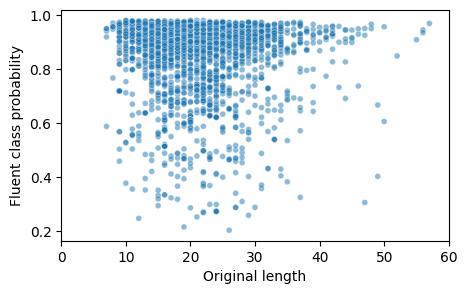

####################################################################################################
count    3105.000000
mean       21.048631
std         7.338064
min         7.000000
25%        16.000000
50%        20.000000
75%        25.000000
max       109.000000
Name: original_len, dtype: float64
####################################################################################################
Mean
original_len_bins
(0, 10]      0.869015
(10, 20]     0.876054
(20, 30]     0.857830
(30, 40]     0.854083
(40, 60]     0.871378
(60, 120]    0.920201
Name: fluency_final_qwen, dtype: float64
####################################################################################################
fluency_final_qwen_class   0     1
original_len_bins                 
(0, 10]                    2    96
(10, 20]                  39  1459
(20, 30]                  47  1180
(30, 40]                   9   223
(40, 60]                   2    44
(60, 120]                  0     4
##################

In [112]:
gpt35_eda['original_len'] = gpt35_eda['original'].apply(lambda x: len(tokenizer(x)['input_ids']))

plt.figure(figsize=(5, 3))
sns.scatterplot(data=gpt35_eda, x='original_len', y='fluency_final_qwen', size=1,alpha=0.5,legend=False)
plt.xlabel('Original length')
plt.ylabel('Fluent class probability')
plt.xlim(0,60)
plt.show()
print('#'*100)
print(gpt35_eda['original_len'].describe())
print('#'*100)
gpt35_eda['original_len_bins'] = pd.cut(gpt35_eda['original_len'], [0,10,20,30,40,60,120])
gpt35_eda['fluency_final_qwen_class'] = gpt35_eda['fluency_final_qwen'].apply(lambda x: 1 if x > 0.5 else 0)
print('Mean')
print(gpt35_eda.groupby('original_len_bins')['fluency_final_qwen'].mean())
print('#'*100)
# print('Median')
# print(gpt35_eda.groupby('original_len_bins')['fluency_final_qwen'].median())
# print('#'*100)
print(gpt35_eda.groupby('original_len_bins')['fluency_final_qwen_class'].value_counts().unstack())
print('#'*100)
print(gpt35_eda.groupby('original_len_bins')['fluency_final_qwen_class'].mean().round(3))
print('#'*100)

### 원본을 다시 뱉는 비율 확인

- 같은 editor model 을 기준으로 비교

In [116]:
(eda['original']==eda['final_qwen']).value_counts()

False    461
True     105
Name: count, dtype: int64

In [119]:
eda['fluency_final_qwen_class'].mean()

0.8975265017667845

In [127]:
eda['final_qwen_updated'] = (eda['original']!=eda['final_qwen'])
eda.groupby(['final_qwen_updated', 'fluency_final_qwen_class']).size()

final_qwen_updated  fluency_final_qwen_class
False               0                             5
                    1                           100
True                0                            53
                    1                           408
dtype: int64

In [117]:
(phi_eda['original']==phi_eda['final_qwen']).value_counts()

False    666
True     545
Name: count, dtype: int64

In [120]:
phi_eda['fluency_final_qwen_class'].mean()

0.8298926507018992

In [126]:
phi_eda['final_qwen_updated'] = (phi_eda['original']!=phi_eda['final_qwen'])
phi_eda.groupby(['final_qwen_updated', 'fluency_final_qwen_class']).size()

final_qwen_updated  fluency_final_qwen_class
False               0                            73
                    1                           472
True                0                           133
                    1                           533
dtype: int64

In [118]:
(gpt35_eda['original']==gpt35_eda['final_qwen']).value_counts()

False    2379
True      726
Name: count, dtype: int64

In [121]:
gpt35_eda['fluency_final_qwen_class'].mean()

0.9681159420289855

In [122]:
gpt35_eda['final_qwen_updated'] = (gpt35_eda['original']!=gpt35_eda['final_qwen'])

In [124]:
gpt35_eda.groupby(['final_qwen_updated', 'fluency_final_qwen_class']).size()

final_qwen_updated  fluency_final_qwen_class
False               0                             11
                    1                            715
True                0                             88
                    1                           2291
dtype: int64

### 눈으로 직접 보기

- Editor model은 qwen 으로 해서 gemma, phi, gpt35 생성문에 대해서 fluent class == 0 인 건들만 눈으로 보기 

In [128]:
eda.loc[(eda['fluency_final_qwen']<0.5) & 
        (eda['final_qwen_updated'])].to_excel('new_module/_notebooks/20250312_analyze_whitebox_result/gemma_edited_by_qwen_nonfluent.xlsx',index=False)

In [129]:
phi_eda.loc[(phi_eda['fluency_final_qwen']<0.5) & 
            (phi_eda['final_qwen_updated'])].to_excel('new_module/_notebooks/20250312_analyze_whitebox_result/phi_edited_by_qwen_nonfluent.xlsx',index=False)

In [130]:
gpt35_eda.loc[(gpt35_eda['fluency_final_qwen']<0.5) &
              (gpt35_eda['final_qwen_updated'])].to_excel('new_module/_notebooks/20250312_analyze_whitebox_result/gpt35_edited_by_qwen_nonfluent.xlsx',index=False)

### 직접봐도 잘 모르겠다 ㅠㅠ

In [133]:
print(f"Average Fluency: Original {eda['fluency_original'].mean():.2f}, Edited {eda['fluency_final_qwen'].mean():.2f}")
print(f"% Fluent: Original {eda['fluency_original'].apply(lambda x: 1 if x > 0.5 else 0).mean():.2f}, Edited {eda['fluency_final_qwen'].apply(lambda x: 1 if x > 0.5 else 0).mean():.2f}")

Average Fluency: Original 0.88, Edited 0.80
% Fluent: Original 0.99, Edited 0.90


In [137]:
print(f"Average Fluency for Instance where Editing Result is Not Fluent: {eda.loc[eda['fluency_final_qwen']<0.5, 'fluency_original'].mean():.2f}")
print(f"Average Fluency for Instance where Editing Result is Fluent: {eda.loc[eda['fluency_final_qwen']>=0.5, 'fluency_original'].mean():.2f}")

Average Fluency for Instance where Editing Result is Not Fluent: 0.84
Average Fluency for Instance where Editing Result is Fluent: 0.89


In [148]:
print(eda.loc[(eda['fluency_final_qwen']<0.5) &
                     (eda['fluency_original']>0.5), 'fluency_original'].mean())
print(eda.loc[(eda['fluency_final_qwen']<0.5) &
                     (eda['fluency_original']>0.5), 'fluency_original'].shape[0])

0.8515532112547329
56


In [134]:
print(f"Average Fluency: Original {phi_eda['fluency_original'].mean():.2f}, Edited {phi_eda['fluency_final_qwen'].mean():.2f}")
print(f"% Fluent: Original {phi_eda['fluency_original'].apply(lambda x: 1 if x > 0.5 else 0).mean():.2f}, Edited {phi_eda['fluency_final_qwen'].apply(lambda x: 1 if x > 0.5 else 0).mean():.2f}")

Average Fluency: Original 0.78, Edited 0.74
% Fluent: Original 0.92, Edited 0.83


In [136]:
print(f"Average Fluency for Instance where Editing Result is Not Fluent: {phi_eda.loc[phi_eda['fluency_final_qwen']<0.5, 'fluency_original'].mean():.2f}")
print(f"Average Fluency for Instance where Editing Result is Fluent: {phi_eda.loc[phi_eda['fluency_final_qwen']>=0.5, 'fluency_original'].mean():.2f}")

Average Fluency for Instance where Editing Result is Not Fluent: 0.60
Average Fluency for Instance where Editing Result is Fluent: 0.82


In [149]:
print(phi_eda.loc[(phi_eda['fluency_final_qwen']<0.5) &
                     (phi_eda['fluency_original']>0.5), 'fluency_original'].mean())
print(phi_eda.loc[(phi_eda['fluency_final_qwen']<0.5) &
                     (phi_eda['fluency_original']>0.5), 'fluency_original'].shape[0])

0.7102957259129433
137


In [135]:
print(f"Average Fluency: Original {gpt35_eda['fluency_original'].mean():.2f}, Edited {gpt35_eda['fluency_final_qwen'].mean():.2f}")
print(f"% Fluent: Original {gpt35_eda['fluency_original'].apply(lambda x: 1 if x > 0.5 else 0).mean():.2f}, Edited {gpt35_eda['fluency_final_qwen'].apply(lambda x: 1 if x > 0.5 else 0).mean():.2f}")

Average Fluency: Original 0.89, Edited 0.87
% Fluent: Original 0.99, Edited 0.97


In [138]:
print(f"Average Fluency for Instance where Editing Result is Not Fluent: {gpt35_eda.loc[gpt35_eda['fluency_final_qwen']<0.5, 'fluency_original'].mean():.2f}")
print(f"Average Fluency for Instance where Editing Result is Fluent: {gpt35_eda.loc[gpt35_eda['fluency_final_qwen']>=0.5, 'fluency_original'].mean():.2f}")

Average Fluency for Instance where Editing Result is Not Fluent: 0.69
Average Fluency for Instance where Editing Result is Fluent: 0.90


In [150]:
print(gpt35_eda.loc[(gpt35_eda['fluency_final_qwen']<0.5) &
                     (gpt35_eda['fluency_original']>0.5), 'fluency_original'].mean())
print(gpt35_eda.loc[(gpt35_eda['fluency_final_qwen']<0.5) &
                     (gpt35_eda['fluency_original']>0.5), 'fluency_original'].shape[0])

0.904591907534683
57


# Old

In [21]:
eda.to_excel('./gemma_edit.xlsx')

In [22]:
gemma_edited = read_outputs('/data/hyeryung/mucoco/outputs/nli/2eencunf/outputs_epsilon0.99.txt.intermediate').drop(columns=['iter0_update'])
gemma_edited_fluency = read_metric_file('/data/hyeryung/mucoco/outputs/nli/2eencunf/results_epsilon0.99-test.txt.fluency', 'fluency')
gemma_original_fluency = read_metric_file('/data/hyeryung/mucoco/new_module/data/logical-consistency/llama/filtered_0.99_r2-test_500_Llama-3.1-8B-Instruct_49578.jsonl-results.txt.fluency', 'fluency')
gemma_original_nli = read_nli_result('/data/hyeryung/mucoco/new_module/data/logical-consistency/llama/filtered_0.99_r2-test_500_Llama-3.1-8B-Instruct_49578.jsonl-results.txt.nli')
gemma_edited_nli = read_nli_result('/data/hyeryung/mucoco/outputs/nli/2eencunf/results_epsilon0.99-test.txt.nli')

In [23]:
eda=pd.concat([gemma_edited,gemma_original_nli[['contradiction_prob', 'nli_class']],gemma_edited_nli[['contradiction_prob', 'nli_class']]], axis=1)
eda.columns=['premise','original','located','edited','original_contradiction_prob', 'original_nli_class', 'edited_contradiction_prob', 'edited_nli_class']
eda['original_fluency']=gemma_original_fluency
eda['edited_fluency']=gemma_edited_fluency

In [25]:
eda.to_excel('./llama_edit.xlsx')

In [26]:
gemma_edited = read_outputs('/data/hyeryung/mucoco/outputs/nli/aqz7ucpi/outputs_epsilon0.99.txt.intermediate').drop(columns=['iter0_update'])
gemma_edited_fluency = read_metric_file('/data/hyeryung/mucoco/outputs/nli/aqz7ucpi/results_epsilon0.99-test.txt.fluency', 'fluency')
gemma_original_fluency = read_metric_file('/data/hyeryung/mucoco/new_module/data/logical-consistency/phi/filtered_0.99_r2-test_500_Phi-3.5-mini-instruct_49611_postprocess.jsonl-results.txt.fluency', 'fluency')
gemma_original_nli = read_nli_result('/data/hyeryung/mucoco/new_module/data/logical-consistency/phi/filtered_0.99_r2-test_500_Phi-3.5-mini-instruct_49611_postprocess.jsonl-results.txt.nli')
gemma_edited_nli = read_nli_result('/data/hyeryung/mucoco/outputs/nli/aqz7ucpi/results_epsilon0.99-test.txt.nli')

In [28]:
eda=pd.concat([gemma_edited,gemma_original_nli[['contradiction_prob', 'nli_class']],gemma_edited_nli[['contradiction_prob', 'nli_class']]], axis=1)
eda.columns=['premise','original','located','edited','original_contradiction_prob', 'original_nli_class', 'edited_contradiction_prob', 'edited_nli_class']
eda['original_fluency']=gemma_original_fluency
eda['edited_fluency']=gemma_edited_fluency

In [30]:
eda.to_excel('./phi_edit.xlsx')

In [ ]:
## 규인에게 전달해줄 원본 생성 파일

gemma_edited = read_outputs('')
